# Mapa estático

In [1]:
!pip install geobr

   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 3.8/3.8 MB 28.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 23.3 MB/s eta 0:00:00
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.1
    Uninstalling shapely-2.1.1:
      Successfully uninstalled shapely-2.1.1
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.1
    Uninstalling geopandas-1.1.1:
      Successfully uninstalled geopandas-1.1.1



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install descartes


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import geobr
import contextily as cx

%matplotlib inline

In [5]:
biomas = geobr.read_biomes()
biomas

,name_biome,code_biome,year,geometry
0,Amazônia,1.0,2019.0,"MULTIPOLYGON (((-44.08515 -2.41669, -44.09068 ..."
1,Caatinga,2.0,2019.0,"MULTIPOLYGON (((-41.7408 -2.80826, -41.73291 -..."
2,Cerrado,3.0,2019.0,"MULTIPOLYGON (((-43.39009 -2.33937, -43.38741 ..."
3,Mata Atlântica,4.0,2019.0,"MULTIPOLYGON (((-48.70814 -28.44851, -48.71072..."
4,Pampa,5.0,2019.0,"MULTIPOLYGON (((-52.82472 -27.46295, -52.80293..."
5,Pantanal,6.0,2019.0,"MULTIPOLYGON (((-57.75946 -15.72779, -57.75659..."
6,Sistema Costeiro,NaN,2019.0,"MULTIPOLYGON (((-44.64799 -2.87038, -44.65184 ..."


In [6]:
biomas_2019 = biomas[:6]

In [7]:
biomas_2019

,name_biome,code_biome,year,geometry
0,Amazônia,1.0,2019.0,"MULTIPOLYGON (((-44.08515 -2.41669, -44.09068 ..."
1,Caatinga,2.0,2019.0,"MULTIPOLYGON (((-41.7408 -2.80826, -41.73291 -..."
2,Cerrado,3.0,2019.0,"MULTIPOLYGON (((-43.39009 -2.33937, -43.38741 ..."
3,Mata Atlântica,4.0,2019.0,"MULTIPOLYGON (((-48.70814 -28.44851, -48.71072..."
4,Pampa,5.0,2019.0,"MULTIPOLYGON (((-52.82472 -27.46295, -52.80293..."
5,Pantanal,6.0,2019.0,"MULTIPOLYGON (((-57.75946 -15.72779, -57.75659..."


In [8]:
biomas_2019.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [9]:
biomas_2019.crs = "EPSG:4674"
biomas_2019.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

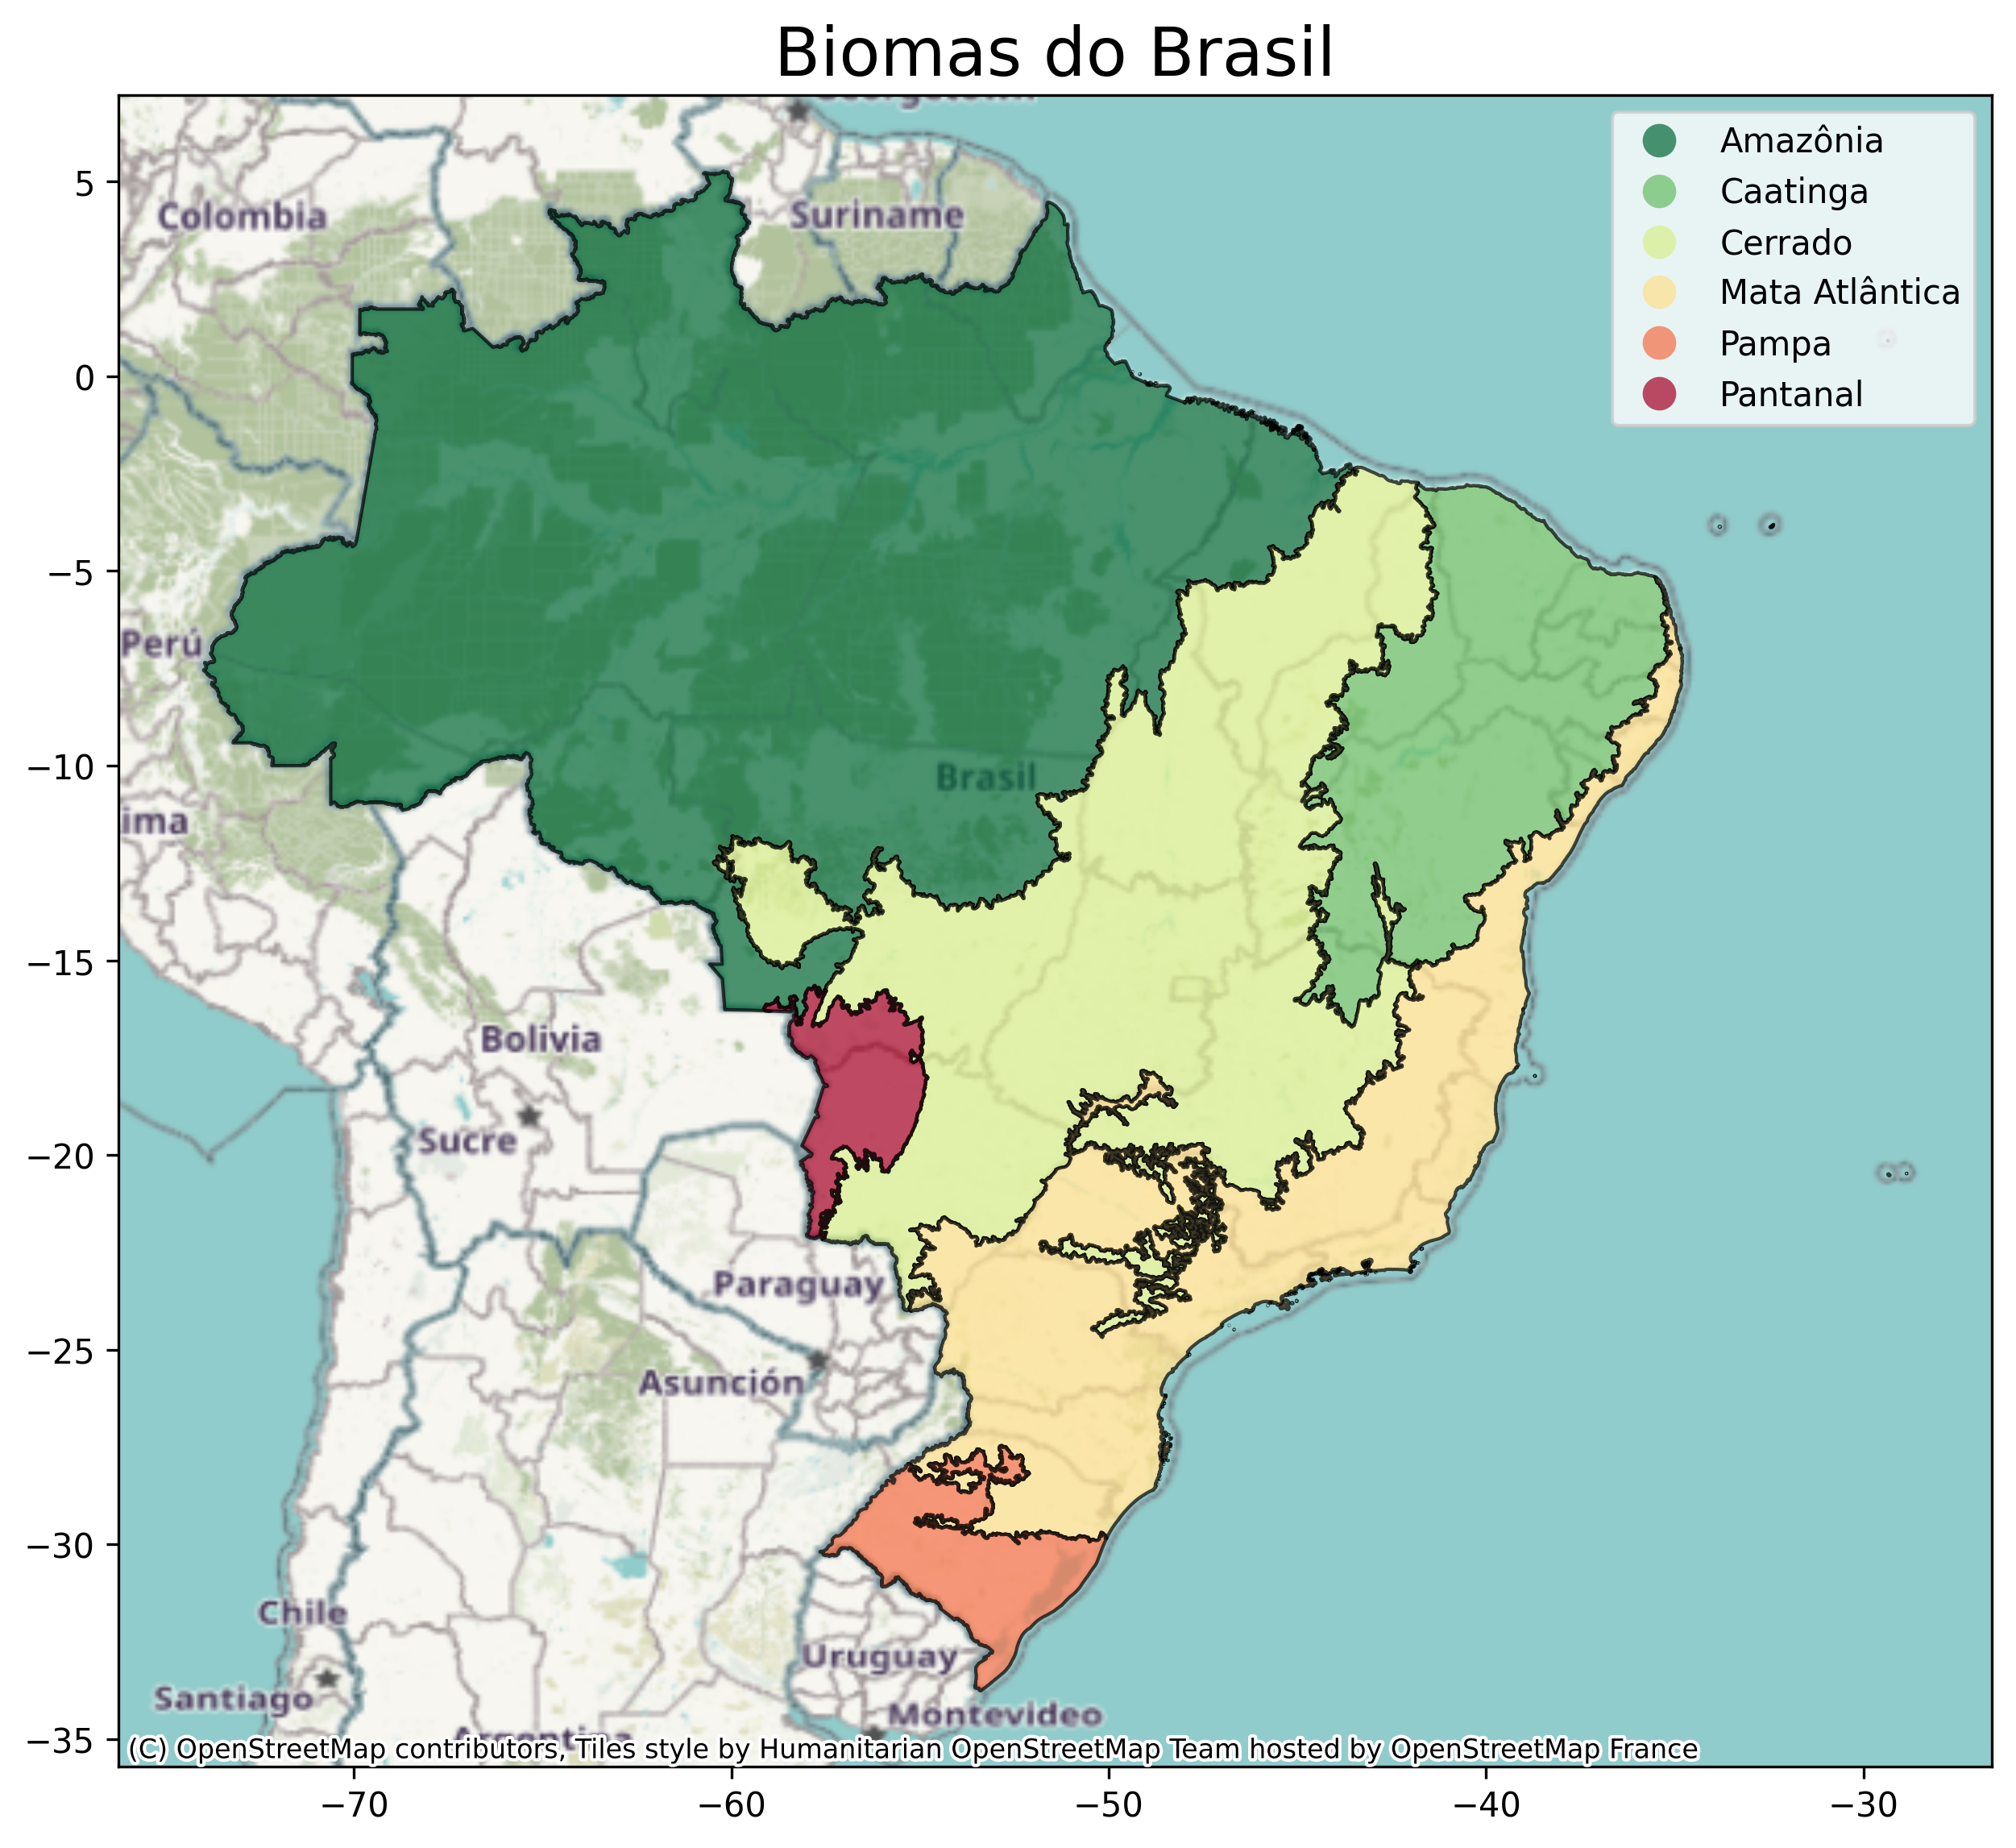

In [10]:
fig, ax = plt.subplots(figsize=(10,10), dpi=300)
biomas_2019.plot(ax=ax, column='name_biome', edgecolor='Black',cmap='RdYlGn_r', legend=True, alpha=0.7)
ax.set_title("Biomas do Brasil", fontsize=20)
cx.add_basemap(ax, crs=biomas_2019.crs)

plt.show()

# Mapa interativo

In [24]:
import folium

In [11]:
est_ar = gpd.read_file(r"C:\AmbientalPro\CursoCompleto\MOD10\dados\est_monit_ar\VWM_ESTACAO_ATIVA_REDEAUTOMATICA_QUALAR_PTOPoint.shp")

DataSourceError: C:\AmbientalPro\CursoCompleto\MOD10\dados\est_monit_ar\VWM_ESTACAO_ATIVA_REDEAUTOMATICA_QUALAR_PTOPoint.shp: No such file or directory

In [26]:
est_ar.head()

,Nome,Endereco,geometry
0,Santana,"AV SANTOS DUMONT, 1019",POINT (-46.62896 -23.50599)
1,Santo Amaro,"AV PE JOSE MARIA, 555",POINT (-46.71000 -23.65498)
2,Mauá,"R VITORINO D ANTONIA, S/N",POINT (-46.46600 -23.66855)
3,Cubatão-V.Parisi,"R PREF ARMANDO CUNHA, 70",POINT (-46.38868 -23.84942)
4,Sorocaba,"R NHONHO PIRES, 260",POINT (-47.47903 -23.50243)


In [27]:
est_ar.shape

(63, 3)

In [39]:
m = folium.Map(location=[-23.54, -46.72], zoom_start=12)

for i, row in est_ar.iterrows():
    folium.Marker([row['geometry'].y, row['geometry'].x], popup=row['Nome']).add_to(m)

m

# Mapa Coroplético

In [40]:
dados_sp = gpd.read_file(r"C:\AmbientalPro\CursoCompleto\MOD10\dados\SP_Setores_2021\sp_setores_censitarios\35SEE250GC_SIR.shp")

C:\Users\limei\Anaconda3\envs\geodev\lib\site-packages\geopandas\array.py:93: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  aout[:] = out


In [41]:
dados_sp.head()

,ID,CD_GEOCODI,TIPO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO,CD_GEOCODB,NM_BAIRRO,ID1,geometry
0,98237.0,354100005000009,URBANO,35410000500,None,354100005,PRAIA GRANDE,3541000,PRAIA GRANDE,SANTOS,METROPOLITANA DE SÃO PAULO,354100005001,Boqueirão,1,"POLYGON ((-46.41024 -24.01103, -46.41169 -24.0..."
1,98232.0,354100005000004,URBANO,35410000500,None,354100005,PRAIA GRANDE,3541000,PRAIA GRANDE,SANTOS,METROPOLITANA DE SÃO PAULO,354100005001,Boqueirão,2,"POLYGON ((-46.41606 -24.00245, -46.41598 -24.0..."
2,98230.0,354100005000002,URBANO,35410000500,None,354100005,PRAIA GRANDE,3541000,PRAIA GRANDE,SANTOS,METROPOLITANA DE SÃO PAULO,354100005001,Boqueirão,3,"POLYGON ((-46.41213 -24.00792, -46.41244 -24.0..."
3,98229.0,354100005000001,URBANO,35410000500,None,354100005,PRAIA GRANDE,3541000,PRAIA GRANDE,SANTOS,METROPOLITANA DE SÃO PAULO,354100005001,Boqueirão,4,"POLYGON ((-46.41134 -24.00552, -46.41196 -24.0..."
4,98231.0,354100005000003,URBANO,35410000500,None,354100005,PRAIA GRANDE,3541000,PRAIA GRANDE,SANTOS,METROPOLITANA DE SÃO PAULO,354100005001,Boqueirão,5,"POLYGON ((-46.41326 -24.00514, -46.41484 -24.0..."


In [42]:
dados_sp.shape

(68296, 15)

In [43]:
mun_sp = dados_sp.loc[dados_sp['NM_MUNICIP'] == 'SÃO PAULO']

In [44]:
mun_sp.head()

,ID,CD_GEOCODI,TIPO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO,CD_GEOCODB,NM_BAIRRO,ID1,geometry
42322,109347.0,355030804000079,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42323,"POLYGON ((-46.51778 -23.57947, -46.51786 -23.5..."
42323,109348.0,355030804000080,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42324,"POLYGON ((-46.51888 -23.57967, -46.51908 -23.5..."
42324,109349.0,355030804000081,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42325,"POLYGON ((-46.52015 -23.58105, -46.52026 -23.5..."
42325,109350.0,355030804000082,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42326,"POLYGON ((-46.52140 -23.57992, -46.52144 -23.5..."
42326,109351.0,355030804000083,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42327,"POLYGON ((-46.52371 -23.58185, -46.52384 -23.5..."


In [45]:
mun_sp.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - SIRGAS 2000 by country
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [46]:
mun_sp_31983 = mun_sp.to_crs("EPSG:31983")

C:\Users\limei\Anaconda3\envs\geodev\lib\site-packages\geopandas\array.py:93: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  aout[:] = out


In [47]:
mun_sp_31983.crs

<Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - 48°W to 42°W
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
# pip install xlrd

In [48]:
import pandas as pd
df = pd.read_excel(r"C:\AmbientalPro\CursoCompleto\MOD10\dados\SP_Setores_2021\sp_setores_censitarios\EXCEL\Basico_SP1.xls")

In [49]:
df.head()

,Cod_setor,Cod_Grandes Regiões,Nome_Grande_Regiao,Cod_UF,Nome_da_UF,Cod_meso,Nome_da_meso,Cod_micro,Nome_da_micro,Cod_RM,...,V003,V004,V005,V006,V007,V008,V009,V010,V011,V012
0,355030801000001,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,3.01,2.32,2091.32,8532451.78,2164.55,8673276.78,1227.41,4285771.99,1713.75,5152087.86
1,355030801000002,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,2.98,2.09,1650.09,3983441.31,1717.44,4030519.99,1045.78,2572133.32,1468.08,2991546.94
2,355030801000003,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,3.31,3.08,1280.43,5474593.06,2349.53,7553913.02,902.97,2735492.52,1786.79,3837674.74
3,355030801000004,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,3.16,2.26,1119.59,3572955.10,1859.13,4567289.50,869.09,2122409.02,1567.41,2735383.24
4,355030801000005,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,3.14,2.35,1416.90,2240207.58,1581.66,2240109.39,917.71,1570047.75,1356.35,1725877.85


In [50]:
df['CD_GEOCODI'] = df['Cod_setor']

In [51]:
df.head()

,Cod_setor,Cod_Grandes Regiões,Nome_Grande_Regiao,Cod_UF,Nome_da_UF,Cod_meso,Nome_da_meso,Cod_micro,Nome_da_micro,Cod_RM,...,V004,V005,V006,V007,V008,V009,V010,V011,V012,CD_GEOCODI
0,355030801000001,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,2.32,2091.32,8532451.78,2164.55,8673276.78,1227.41,4285771.99,1713.75,5152087.86,355030801000001
1,355030801000002,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,2.09,1650.09,3983441.31,1717.44,4030519.99,1045.78,2572133.32,1468.08,2991546.94,355030801000002
2,355030801000003,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,3.08,1280.43,5474593.06,2349.53,7553913.02,902.97,2735492.52,1786.79,3837674.74,355030801000003
3,355030801000004,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,2.26,1119.59,3572955.10,1859.13,4567289.50,869.09,2122409.02,1567.41,2735383.24,355030801000004
4,355030801000005,3,Região Sudeste,SP,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,2.35,1416.90,2240207.58,1581.66,2240109.39,917.71,1570047.75,1356.35,1725877.85,355030801000005


In [52]:
mun_sp_31983['Area'] = mun_sp_31983.area

In [53]:
mun_sp_31983.head()

,ID,CD_GEOCODI,TIPO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO,CD_GEOCODB,NM_BAIRRO,ID1,geometry,Area
42322,109347.0,355030804000079,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42323,"POLYGON ((345114.562 7391509.505, 345106.759 7...",35855.126269
42323,109348.0,355030804000080,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42324,"POLYGON ((345002.927 7391486.947, 344983.085 7...",36306.540846
42324,109349.0,355030804000081,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42325,"POLYGON ((344874.928 7391332.868, 344864.237 7...",22269.768083
42325,109350.0,355030804000082,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42326,"POLYGON ((344746.124 7391456.534, 344742.477 7...",36717.318957
42326,109351.0,355030804000083,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,METROPOLITANA DE SÃO PAULO,None,None,42327,"POLYGON ((344512.429 7391240.196, 344500.243 7...",29148.461002


In [54]:
mun_sp_31983.reset_index(drop=True, inplace=True)

In [55]:
mun_sp_31983.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 18953 entries, 0 to 18952
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   ID          18953 non-null  float64 
 1   CD_GEOCODI  18953 non-null  object  
 2   TIPO        18953 non-null  object  
 3   CD_GEOCODS  18953 non-null  object  
 4   NM_SUBDIST  0 non-null      object  
 5   CD_GEOCODD  18953 non-null  object  
 6   NM_DISTRIT  18953 non-null  object  
 7   CD_GEOCODM  18953 non-null  object  
 8   NM_MUNICIP  18953 non-null  object  
 9   NM_MICRO    18953 non-null  object  
 10  NM_MESO     18953 non-null  object  
 11  CD_GEOCODB  0 non-null      object  
 12  NM_BAIRRO   0 non-null      object  
 13  ID1         18953 non-null  int64   
 14  geometry    18953 non-null  geometry
 15  Area        18953 non-null  float64 
dtypes: float64(2), geometry(1), int64(1), object(12)
memory usage: 2.3+ MB


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18363 entries, 0 to 18362
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cod_setor            18363 non-null  int64  
 1   Cod_Grandes Regiões  18363 non-null  int64  
 2   Nome_Grande_Regiao   18363 non-null  object 
 3   Cod_UF               18363 non-null  object 
 4   Nome_da_UF           18363 non-null  object 
 5   Cod_meso             18363 non-null  int64  
 6   Nome_da_meso         18363 non-null  object 
 7   Cod_micro            18363 non-null  int64  
 8   Nome_da_micro        18363 non-null  object 
 9   Cod_RM               18363 non-null  int64  
 10  Nome_da_RM           18363 non-null  object 
 11  Cod_municipio        18363 non-null  int64  
 12  Nome_do_municipio    18363 non-null  object 
 13  Cod_distrito         18363 non-null  int64  
 14  Nome_do_distrito     18363 non-null  object 
 15  Cod_subdistrito      18363 non-null 

In [58]:
mun_sp_31983['CD_GEOCODI'] = mun_sp_31983['CD_GEOCODI'].astype('int64')

In [59]:
mun_sp_31983.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 18953 entries, 0 to 18952
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   ID          18953 non-null  float64 
 1   CD_GEOCODI  18953 non-null  int64   
 2   TIPO        18953 non-null  object  
 3   CD_GEOCODS  18953 non-null  object  
 4   NM_SUBDIST  0 non-null      object  
 5   CD_GEOCODD  18953 non-null  object  
 6   NM_DISTRIT  18953 non-null  object  
 7   CD_GEOCODM  18953 non-null  object  
 8   NM_MUNICIP  18953 non-null  object  
 9   NM_MICRO    18953 non-null  object  
 10  NM_MESO     18953 non-null  object  
 11  CD_GEOCODB  0 non-null      object  
 12  NM_BAIRRO   0 non-null      object  
 13  ID1         18953 non-null  int64   
 14  geometry    18953 non-null  geometry
 15  Area        18953 non-null  float64 
dtypes: float64(2), geometry(1), int64(2), object(11)
memory usage: 2.3+ MB


In [60]:
df  = mun_sp_31983.merge(df, on='CD_GEOCODI', how='left')
gdf = gpd.GeoDataFrame(df)

In [61]:
gdf

,ID,CD_GEOCODI,TIPO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,...,V003,V004,V005,V006,V007,V008,V009,V010,V011,V012
0,109347.0,355030804000079,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,3.09,2.11,1335.48,3982486.43,1397.96,4082041.23,860.76,1933007.93,1241.68,2316552.19
1,109348.0,355030804000080,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,3.00,2.82,998.03,787438.49,1125.73,744229.10,708.58,626557.02,1047.18,571259.43
2,109349.0,355030804000081,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,3.37,2.78,1057.50,1098171.92,1270.25,1048565.77,697.24,735503.32,1082.56,724807.31
3,109350.0,355030804000082,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,3.23,2.25,1296.16,28854714.26,1586.09,34875611.24,777.64,10751997.93,1304.12,17358390.21
4,109351.0,355030804000083,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,3.24,2.57,893.58,717708.36,1051.93,678067.75,592.82,474377.58,919.90,435113.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18948,127887.0,355030896000243,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,3.50,2.61,772.09,168751.10,814.52,143188.21,467.46,191332.48,699.95,123399.08
18949,127888.0,355030896000244,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,3.87,2.49,692.50,239941.27,812.93,182516.20,439.33,194034.99,702.10,124952.38
18950,127889.0,355030896000245,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,3.90,2.54,630.06,329705.22,843.31,260395.90,347.60,228162.66,767.50,181129.99
18951,127890.0,355030896000246,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,4.29,4.21,597.37,349101.00,908.00,244391.67,397.76,436942.16,854.20,550319.43


In [62]:
gdf['Area_ha'] = gdf['Area'] / 10000

In [63]:
gdf

,ID,CD_GEOCODI,TIPO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,...,V004,V005,V006,V007,V008,V009,V010,V011,V012,Area_ha
0,109347.0,355030804000079,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,2.11,1335.48,3982486.43,1397.96,4082041.23,860.76,1933007.93,1241.68,2316552.19,3.585513
1,109348.0,355030804000080,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,2.82,998.03,787438.49,1125.73,744229.10,708.58,626557.02,1047.18,571259.43,3.630654
2,109349.0,355030804000081,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,2.78,1057.50,1098171.92,1270.25,1048565.77,697.24,735503.32,1082.56,724807.31,2.226977
3,109350.0,355030804000082,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,2.25,1296.16,28854714.26,1586.09,34875611.24,777.64,10751997.93,1304.12,17358390.21,3.671732
4,109351.0,355030804000083,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,2.57,893.58,717708.36,1051.93,678067.75,592.82,474377.58,919.90,435113.89,2.914846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18948,127887.0,355030896000243,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,2.61,772.09,168751.10,814.52,143188.21,467.46,191332.48,699.95,123399.08,1.023843
18949,127888.0,355030896000244,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,2.49,692.50,239941.27,812.93,182516.20,439.33,194034.99,702.10,124952.38,0.892076
18950,127889.0,355030896000245,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,2.54,630.06,329705.22,843.31,260395.90,347.60,228162.66,767.50,181129.99,1.107274
18951,127890.0,355030896000246,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,4.21,597.37,349101.00,908.00,244391.67,397.76,436942.16,854.20,550319.43,0.811238


In [64]:
gdf['dens_ha'] = gdf['V002'] // gdf['Area_ha']

In [65]:
gdf

,ID,CD_GEOCODI,TIPO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,...,V005,V006,V007,V008,V009,V010,V011,V012,Area_ha,dens_ha
0,109347.0,355030804000079,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,1335.48,3982486.43,1397.96,4082041.23,860.76,1933007.93,1241.68,2316552.19,3.585513,154.0
1,109348.0,355030804000080,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,998.03,787438.49,1125.73,744229.10,708.58,626557.02,1047.18,571259.43,3.630654,196.0
2,109349.0,355030804000081,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,1057.50,1098171.92,1270.25,1048565.77,697.24,735503.32,1082.56,724807.31,2.226977,307.0
3,109350.0,355030804000082,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,1296.16,28854714.26,1586.09,34875611.24,777.64,10751997.93,1304.12,17358390.21,3.671732,245.0
4,109351.0,355030804000083,URBANO,35503080400,None,355030804,ARICANDUVA,3550308,SÃO PAULO,SÃO PAULO,...,893.58,717708.36,1051.93,678067.75,592.82,474377.58,919.90,435113.89,2.914846,206.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18948,127887.0,355030896000243,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,772.09,168751.10,814.52,143188.21,467.46,191332.48,699.95,123399.08,1.023843,328.0
18949,127888.0,355030896000244,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,692.50,239941.27,812.93,182516.20,439.33,194034.99,702.10,124952.38,0.892076,234.0
18950,127889.0,355030896000245,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,630.06,329705.22,843.31,260395.90,347.60,228162.66,767.50,181129.99,1.107274,306.0
18951,127890.0,355030896000246,URBANO,35503089600,None,355030896,LAJEADO,3550308,SÃO PAULO,SÃO PAULO,...,597.37,349101.00,908.00,244391.67,397.76,436942.16,854.20,550319.43,0.811238,200.0


C:\Users\limei\Anaconda3\envs\geodev\lib\site-packages\geopandas\plotting.py:33: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for poly in geom:
C:\Users\limei\Anaconda3\envs\geodev\lib\site-packages\descartes\patch.py:65: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  for t in polygon])


<AxesSubplot:>

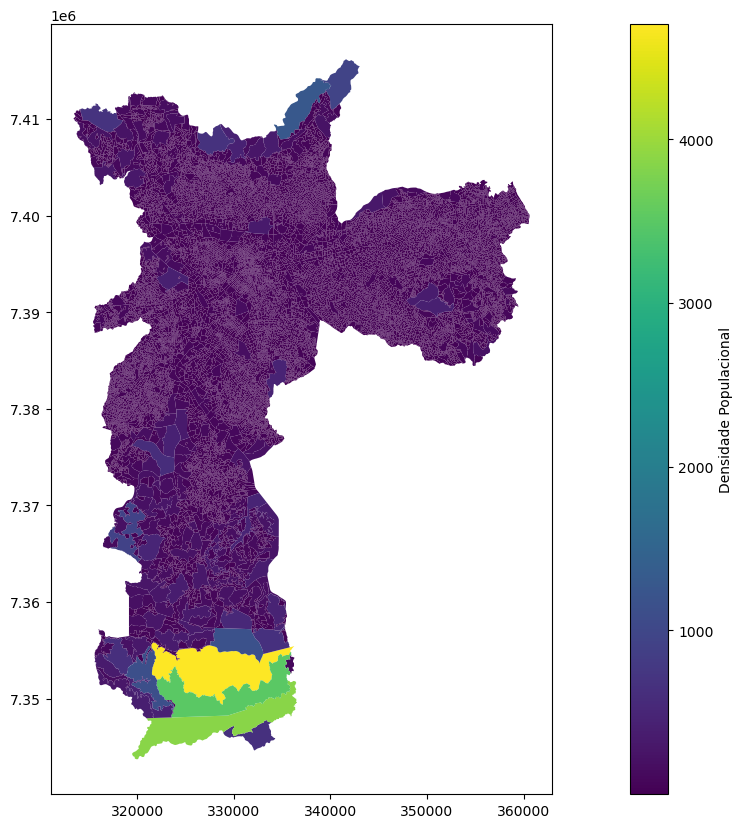

In [70]:
gdf.plot(column = 'Area_ha',
                      legend = True,
                      figsize = [20,10],
                      legend_kwds = {'label': "Densidade Populacional"})

In [69]:
gdf['dens_ha'].mean()

345.17705776468665